<a href="https://colab.research.google.com/github/WahyuKhairi06/BigData_2311531009_Wahyu-Khairi/blob/main/Tugas%20Besar%20Big%20data_part2/Tugas_besar_big_data_praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS BESAR PRAKTIKUM BIG DATA**

**IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib


**LOAD DATASET**

In [3]:
url = "https://raw.githubusercontent.com/WahyuKhairi06/BigData_2311531009_Wahyu-Khairi/refs/heads/main/TB%20Praktikum/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(url)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**CEK STRUKTUR DATA**

In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


**DISTRIBUSI KELAS (SEBELUM BALANCING)**

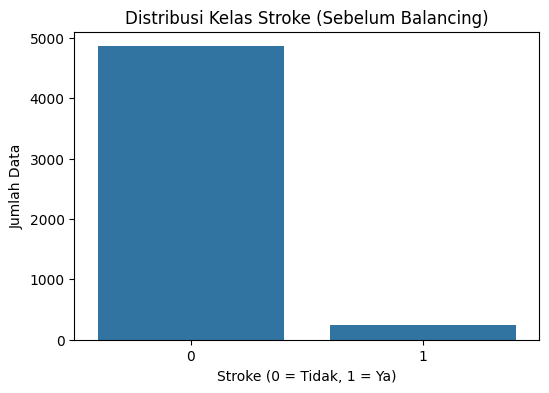

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="stroke", data=df)
plt.title("Distribusi Kelas Stroke (Sebelum Balancing)")
plt.xlabel("Stroke (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Data")
plt.show()


**PISAHKAN FITUR & LABEL**

In [6]:
X = df.drop("stroke", axis=1)
y = df["stroke"]


**TRAIN–TEST SPLIT (STRATIFIED)**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


**DEFINISI FITUR**

In [8]:
numerical_features = ["age", "avg_glucose_level", "bmi"]
binary_features = ["hypertension", "heart_disease"]
categorical_features = [
    "gender", "ever_married", "work_type",
    "Residence_type", "smoking_status"
]


**PREPROCESSING PIPELINE**

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("bin", "passthrough", binary_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


======================================================
MODEL 1 — TANPA SMOTE (BASELINE)
======================================================

**PIPELINE TANPA SMOTE**

In [12]:
pipeline_no_smote = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline_no_smote.fit(X_train, y_train)

y_pred_no = pipeline_no_smote.predict(X_test)
y_prob_no = pipeline_no_smote.predict_proba(X_test)[:,1]


**EVALUASI TANPA SMOTE**

In [13]:
print("=== MODEL TANPA SMOTE ===")
print(classification_report(y_test, y_pred_no))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_no))


=== MODEL TANPA SMOTE ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8420781893004116


======================================================
MODEL 2 — DENGAN SMOTE
======================================================

**PIPELINE DENGAN SMOTE**

In [14]:
pipeline_smote = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline_smote.fit(X_train, y_train)

y_pred_sm = pipeline_smote.predict(X_test)
y_prob_sm = pipeline_smote.predict_proba(X_test)[:,1]


**EVALUASI DENGAN SMOTE**

In [15]:
print("=== MODEL DENGAN SMOTE ===")
print(classification_report(y_test, y_pred_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_sm))


=== MODEL DENGAN SMOTE ===
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.95      0.75      0.82      1022

ROC-AUC: 0.8454115226337449


**DISTRIBUSI KELAS SETELAH SMOTE (VISUAL)**

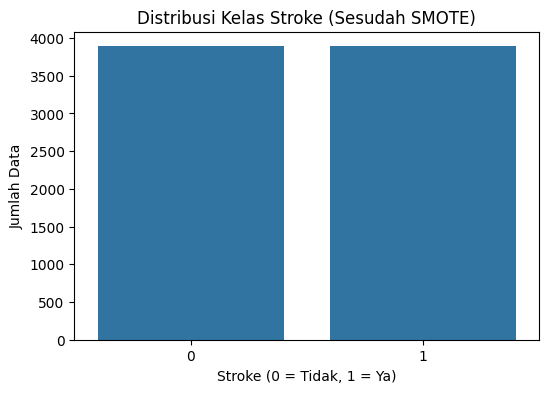

In [16]:
X_tmp = preprocessor.fit_transform(X_train)
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_tmp, y_train)

plt.figure(figsize=(6,4))
sns.countplot(x=y_sm)
plt.title("Distribusi Kelas Stroke (Sesudah SMOTE)")
plt.xlabel("Stroke (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Data")
plt.show()


**PERBANDINGAN ROC CURVE**

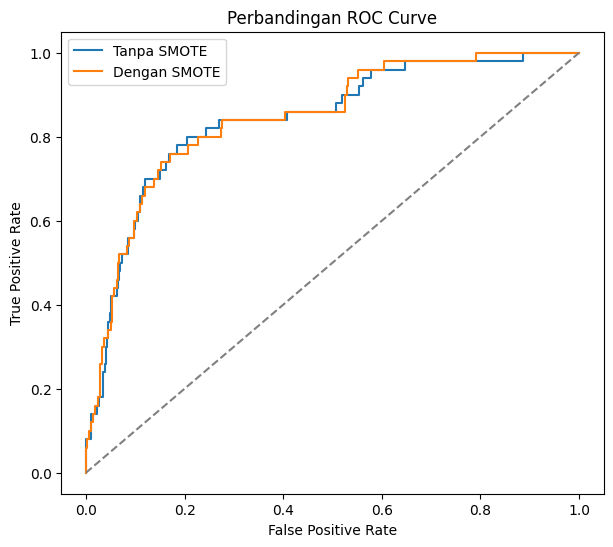

In [17]:
fpr_no, tpr_no, _ = roc_curve(y_test, y_prob_no)
fpr_sm, tpr_sm, _ = roc_curve(y_test, y_prob_sm)

plt.figure(figsize=(7,6))
plt.plot(fpr_no, tpr_no, label="Tanpa SMOTE")
plt.plot(fpr_sm, tpr_sm, label="Dengan SMOTE")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Perbandingan ROC Curve")
plt.legend()
plt.show()


======================================================
MODEL FINAL — GRIDSEARCHCV + SMOTE
======================================================

**PIPELINE GRIDSEARCH + SMOTE**

In [18]:
pipeline_grid = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])


**PARAMETER GRIDSEARCH**

In [19]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}


**GRIDSEARCHCV (ROC-AUC)**

In [20]:
grid = GridSearchCV(
    pipeline_grid,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('bin',
                                                                         'passthrough',
                                                                         ['hypertension',
                                                                          'heart_disease']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'Residence_type',
                                                                          'smoking_status'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear']},
             scoring='roc_auc')

**MODEL TERBAIK**

In [21]:
best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)


Best Parameters:
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


**EVALUASI MODEL FINAL**

In [22]:
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:,1]

print("=== MODEL FINAL (GRIDSEARCH + SMOTE) ===")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))


=== MODEL FINAL (GRIDSEARCH + SMOTE) ===
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.82      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.95      0.73      0.81      1022

ROC-AUC: 0.8401234567901235


**SIMPAN MODEL (SIAP STREAMLIT)**

In [23]:
joblib.dump(best_model, "stroke_model.joblib")


['stroke_model.joblib']